# iFood Case — Notebook 1: Data Processing

**Goal:** transform the three raw files (`offers.json`, `profile.json`, `transactions.json`) into a
**unified dataset at the (customer, offer received) level**, ready for heterogeneous treatment
effect estimation (CATE via Double Machine Learning) in Notebook 2.

**Pipeline overview:**

```
raw JSONs ──► schema standardization ──► typed event tables ──► EDA
                                              │
                                              ▼
                    customer-offer instances (1 row per 'offer received')
                                              │
                    ┌─────────────────────────┼─────────────────────────┐
                    ▼                         ▼                         ▼
        pre-treatment features       treatment variables        outcome variables
        (RFM, offer history,         (offer type, discount      (fixed-window conversion,
         demographics)                intensity, channels)       post-offer retention, net value)
                    └─────────────────────────┼─────────────────────────┘
                                              ▼
                                dataset_unified.parquet (UC Volume)
```

**Key design decisions** (full list with rationale in Section 12 — Assumptions):
1. Unit of analysis = *instance* (customer, offer received). A customer can receive the same offer more than once.
2. Treatment defined by **receipt** (intention-to-treat), not viewing — viewing is post-treatment and conditioning on it would introduce selection bias.
3. `informational` offers (zero discount) form the natural comparison group, holding the effect of *receiving a communication* constant.
4. **Fixed-horizon outcomes** (7-day conversion; retention in days 10–17 after receipt) — offer durations vary with treatment, so outcome windows tied to duration would mechanically confound the effect estimates.
5. Every feature uses **only events strictly before** the offer receipt time.

**Environment:** built for Databricks Free Edition (serverless compute) using a Unity Catalog
Volume for storage. Runs locally with vanilla PySpark by pointing the paths to a local directory.


## 0. Setup and parameters

In [0]:
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window
import os, glob, tarfile, shutil, urllib.request

spark = SparkSession.builder.appName("ifood-case-processing").getOrCreate()
spark.conf.set("spark.sql.shuffle.partitions", "8")   # small dataset; avoids shuffle overhead

# --- Global parameters ---------------------------------------------------
DATA_URL = "https://data-architect-test-source.s3.sa-east-1.amazonaws.com/ds-technical-evaluation-data.tar.gz"

# Unity Catalog Volume: visible to Spark on serverless compute (unlike the driver's /tmp).
# If CREATE VOLUME fails due to permissions, create it once via the UI:
# Catalog -> workspace -> default -> Create -> Volume -> "ifood_case".
spark.sql("CREATE VOLUME IF NOT EXISTS workspace.default.ifood_case")
VOLUME        = "/Volumes/workspace/default/ifood_case"
DIR_RAW       = f"{VOLUME}/raw"
DIR_PROCESSED = f"{VOLUME}/processed"

# Outcome horizons (days). See Section 7 for the rationale behind fixed horizons.
CONV_HORIZON      = 7     # y1: conversion within (t0, t0 + 7]
RETENTION_START   = 10    # y2: repurchase within (t0 + 10, t0 + 17]
RETENTION_END     = 17    #     (max offer duration is 10d, so this window is post-expiry for ALL offers)

os.makedirs(DIR_RAW, exist_ok=True)
os.makedirs(DIR_PROCESSED, exist_ok=True)
print("Spark", spark.version)

Spark 4.1.0


## 1. Ingestion

Download the tarball to the driver's local disk, extract, copy the JSONs into the Volume
(Spark on serverless cannot read the driver's local filesystem), then read with `spark.read.json`
— with a fallback for multi-line JSON in case the file format differs.

In [0]:
tar_local = "/tmp/ifood_data.tar.gz"
if not os.path.exists(tar_local):
    print("Downloading data...")
    urllib.request.urlretrieve(DATA_URL, tar_local)
with tarfile.open(tar_local) as t:
    t.extractall("/tmp/ifood_extracted")

# Copy JSONs into the Volume so Spark executors can read them
for f in glob.glob("/tmp/ifood_extracted/**/*.json", recursive=True):
    shutil.copy(f, DIR_RAW)
print("Files in the Volume:", os.listdir(DIR_RAW))

Files in the Volume: ['offers.json', 'transactions.json', 'profile.json']


In [0]:
def read_json(path):
    """Read line-delimited JSON; if Spark flags it as corrupt, retry in multiLine mode."""
    df = spark.read.json(path)
    if "_corrupt_record" in df.columns:
        df = spark.read.option("multiLine", True).json(path)
    return df

offers_raw  = read_json(f"{DIR_RAW}/offers.json")
profile_raw = read_json(f"{DIR_RAW}/profile.json")
trans_raw   = read_json(f"{DIR_RAW}/transactions.json")

for name, df in [("offers", offers_raw), ("profile", profile_raw), ("transactions", trans_raw)]:
    print(f"--- {name}: {df.count():,} rows")
    df.printSchema()

--- offers: 10 rows
root
 |-- channels: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- discount_value: long (nullable = true)
 |-- duration: double (nullable = true)
 |-- id: string (nullable = true)
 |-- min_value: long (nullable = true)
 |-- offer_type: string (nullable = true)

--- profile: 17,000 rows
root
 |-- age: long (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- id: string (nullable = true)
 |-- registered_on: string (nullable = true)

--- transactions: 306,534 rows
root
 |-- account_id: string (nullable = true)
 |-- event: string (nullable = true)
 |-- time_since_test_start: double (nullable = true)
 |-- value: struct (nullable = true)
 |    |-- amount: double (nullable = true)
 |    |-- offer id: string (nullable = true)
 |    |-- offer_id: string (nullable = true)
 |    |-- reward: double (nullable = true)



## 2. Schema standardization

The case brief documents fields as `discount_value`, `min_value`, `registered_on`,
`credit_card_limit`, `account_id`, `time_since_test_start`. Public versions of this dataset
circulate with alternative names (`reward`, `difficulty`, `became_member_on`, `income`, `person`,
`time`). The block below normalizes to the brief's names regardless of which version is supplied.

We also **auto-detect the time unit**: if the maximum event time is far above ~30, events are in
**hours** and we convert to **days** (the brief specifies days).

In [0]:
def rename_if_present(df, mapping):
    """Rename columns from `mapping` keys to values when the old name exists and the new one doesn't."""
    for old, new in mapping.items():
        if old in df.columns and new not in df.columns:
            df = df.withColumnRenamed(old, new)
    return df

offers  = rename_if_present(offers_raw,  {"reward": "discount_value", "difficulty": "min_value"})
profile = rename_if_present(profile_raw, {"became_member_on": "registered_on", "income": "credit_card_limit"})
trans   = rename_if_present(trans_raw,   {"person": "account_id", "time": "time_since_test_start"})

# --- Time unit detection ---------------------------------------------------
t_max_raw = trans.agg(F.max("time_since_test_start")).first()[0]
IN_HOURS = t_max_raw > 100                # the test lasts ~30 days; 100 is a safe threshold
trans = trans.withColumn("t_days", F.col("time_since_test_start") / F.lit(24.0 if IN_HOURS else 1.0))
T_MAX_DAYS = trans.agg(F.max("t_days")).first()[0]
print(f"raw t_max = {t_max_raw} -> unit detected: {'hours' if IN_HOURS else 'days'}")
print(f"Test duration: {T_MAX_DAYS:.1f} days")

raw t_max = 29.75 -> unit detected: days
Test duration: 29.8 days


### 2.1 Parsing the `value` field

`value` is a heterogeneous JSON: its keys change with the event type (`offer id` in
*received/viewed*, `offer_id` in *completed*, `amount` in *transaction*, `reward` in *completed*).
The helper below coalesces whichever variants exist in the inferred schema.

In [0]:
def value_field(df, *names):
    """Return the first sub-column of `value` present among `names` (coalesced), else NULL."""
    dtype = df.schema["value"].dataType
    if isinstance(dtype, T.StructType):
        present = [F.col(f"value.`{n}`").cast("string") for n in dtype.fieldNames() if n in names]
        return F.coalesce(*present) if present else F.lit(None).cast("string")
    # fallback: `value` arrived as a raw JSON string
    return F.coalesce(*[F.get_json_object("value", f"$['{n}']") for n in names])

trans = (trans
    .withColumn("event_norm",  F.lower(F.regexp_replace("event", "[ _-]+", " ")))
    .withColumn("offer_id",    value_field(trans, "offer_id", "offer id"))
    .withColumn("tx_amount",   value_field(trans, "amount").cast("double"))
    .withColumn("reward_paid", value_field(trans, "reward").cast("double"))
)
trans.groupBy("event_norm").count().orderBy("event_norm").show(truncate=False)

+---------------+------+
|event_norm     |count |
+---------------+------+
|offer completed|33579 |
|offer received |76277 |
|offer viewed   |57725 |
|transaction    |138953|
+---------------+------+



## 3. Typed event tables

In [0]:
received_ev  = trans.filter(F.col("event_norm") == "offer received") \
                     .select("account_id", "offer_id", "t_days")
viewed_ev    = trans.filter(F.col("event_norm") == "offer viewed") \
                     .select("account_id", "offer_id", "t_days")
completed_ev = trans.filter(F.col("event_norm") == "offer completed") \
                     .select("account_id", "offer_id", "t_days", "reward_paid")
transactions = trans.filter(F.col("event_norm") == "transaction") \
                     .select("account_id", "t_days", "tx_amount")

for name, df in [("received", received_ev), ("viewed", viewed_ev),
                 ("completed", completed_ev), ("transactions", transactions)]:
    print(f"{name:12s}: {df.count():>7,} events")

received    :  76,277 events
viewed      :  57,725 events
completed   :  33,579 events
transactions: 138,953 events


## 4. Exploratory data analysis

Views in this section motivate the modeling choices: the wave structure of the experiment,
the delivery funnel, the "pure subsidy" problem, purchase dynamics around sends, and data quality.

### 4.1 Send waves and offer portfolio

In [0]:
print("Send waves (days with 'offer received' events):")
received_ev.groupBy("t_days").count().orderBy("t_days").show()

offers.orderBy("offer_type", "discount_value").show(truncate=False)

Send waves (days with 'offer received' events):
+------+-----+
|t_days|count|
+------+-----+
|   0.0|12650|
|   7.0|12669|
|  14.0|12711|
|  17.0|12778|
|  21.0|12704|
|  24.0|12765|
+------+-----+

+----------------------------+--------------+--------+--------------------------------+---------+-------------+
|channels                    |discount_value|duration|id                              |min_value|offer_type   |
+----------------------------+--------------+--------+--------------------------------+---------+-------------+
|[web, email, mobile, social]|5             |5.0     |f19421c1d4aa40978ebb69ca19b0e20d|5        |bogo         |
|[web, email, mobile]        |5             |7.0     |9b98b8c7a33c4b65b9aebfe6a799e6d9|5        |bogo         |
|[email, mobile, social]     |10            |7.0     |ae264e3637204a6fb9bb56bc8210ddfd|10       |bogo         |
|[web, email, mobile, social]|10            |5.0     |4d5c57ea9a6940dd891ad53e9dbe8da0|10       |bogo         |
|[web, email, mob

### 4.2 Daily transaction volume with send waves marked

Spikes right after each wave followed by shallow troughs are the first visual hint of **purchase pull-forward** — the mechanism behind the retention findings later on.

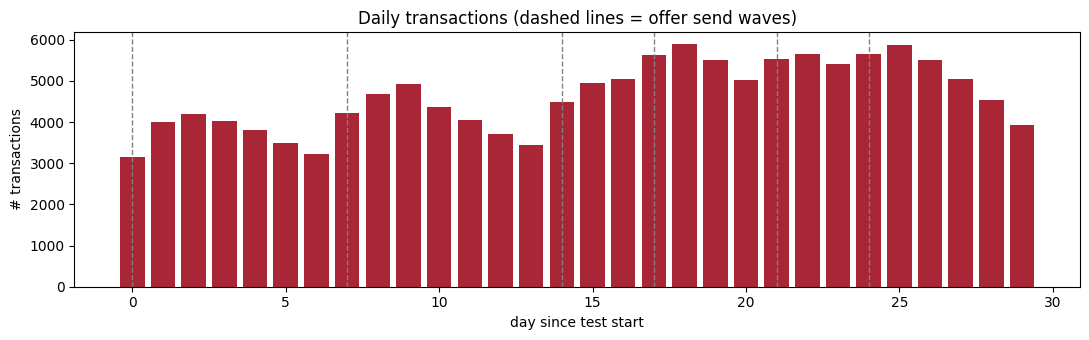

In [0]:
import matplotlib.pyplot as plt

daily = (transactions.withColumn("day", F.floor("t_days"))
         .groupBy("day").agg(F.count("*").alias("n_tx"),
                             F.sum("tx_amount").alias("volume"))
         .orderBy("day").toPandas())
waves = [r["t_days"] for r in received_ev.select("t_days").distinct().collect()]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(daily["day"], daily["n_tx"], color="#990011", alpha=0.85)
for w in waves:
    ax.axvline(w, color="gray", ls="--", lw=1)
ax.set_xlabel("day since test start"); ax.set_ylabel("# transactions")
ax.set_title("Daily transactions (dashed lines = offer send waves)")
plt.tight_layout(); plt.show()

### 4.3 Delivery funnel: received → viewed → completed, per offer

In [0]:
funnel = (received_ev.groupBy("offer_id").agg(F.count("*").alias("received"))
    .join(viewed_ev.groupBy("offer_id").agg(F.count("*").alias("viewed")), "offer_id", "left")
    .join(completed_ev.groupBy("offer_id").agg(F.count("*").alias("completed")), "offer_id", "left")
    .join(offers.select(F.col("id").alias("offer_id"), "offer_type", "discount_value",
                        "min_value", "duration", "channels"), "offer_id")
    .fillna(0, ["viewed", "completed"])
    .withColumn("view_rate",       F.round(F.col("viewed") / F.col("received"), 3))
    .withColumn("completion_rate", F.round(F.col("completed") / F.col("received"), 3))
)
funnel.orderBy("offer_type", "discount_value").show(truncate=False)

+--------------------------------+--------+------+---------+-------------+--------------+---------+--------+----------------------------+---------+---------------+
|offer_id                        |received|viewed|completed|offer_type   |discount_value|min_value|duration|channels                    |view_rate|completion_rate|
+--------------------------------+--------+------+---------+-------------+--------------+---------+--------+----------------------------+---------+---------------+
|f19421c1d4aa40978ebb69ca19b0e20d|7571    |7264  |4296     |bogo         |5             |5        |5.0     |[web, email, mobile, social]|0.959    |0.567          |
|9b98b8c7a33c4b65b9aebfe6a799e6d9|7677    |4171  |4354     |bogo         |5             |5        |7.0     |[web, email, mobile]        |0.543    |0.567          |
|4d5c57ea9a6940dd891ad53e9dbe8da0|7593    |7298  |3331     |bogo         |10            |10       |5.0     |[web, email, mobile, social]|0.961    |0.439          |
|ae264e3637204a6

### 4.4 Delivery matters: view rate × completion rate

Channel mix drives whether an offer is even *seen* — a preview of the treatment-effect ranking in Notebook 2 (under intention-to-treat, effect ≈ P(view) × effect-if-viewed).

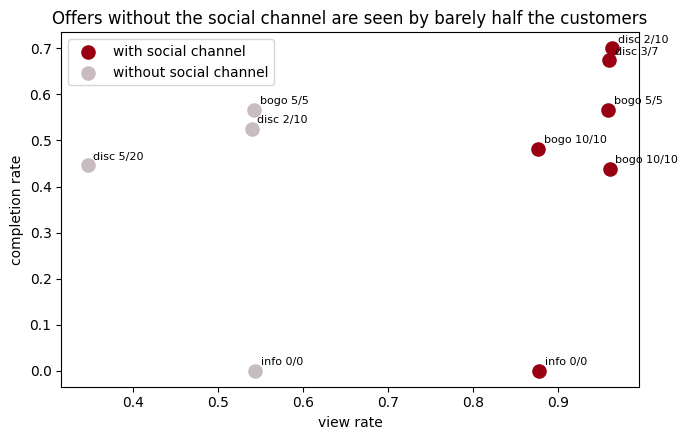

In [0]:
fp = funnel.toPandas()
has_social = fp["channels"].apply(lambda c: "social" in c)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(fp.loc[has_social, "view_rate"], fp.loc[has_social, "completion_rate"],
           s=90, color="#990011", label="with social channel")
ax.scatter(fp.loc[~has_social, "view_rate"], fp.loc[~has_social, "completion_rate"],
           s=90, color="#C9BCBE", label="without social channel")
for _, r in fp.iterrows():
    ax.annotate(f'{r["offer_type"][:4]} {r["discount_value"]}/{r["min_value"]}',
                (r["view_rate"], r["completion_rate"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("view rate"); ax.set_ylabel("completion rate"); ax.legend()
ax.set_title("Offers without the social channel are seen by barely half the customers")
plt.tight_layout(); plt.show()

### 4.5 The pure-subsidy problem: completions without a prior view

Customers who **complete an offer without ever seeing it** would have purchased anyway — the
discount paid to them is pure subsidy. This is the core motivation for modeling *incremental*
effects instead of purchase propensity.

In [0]:
seen_before = (completed_ev.alias("c")
    .join(viewed_ev.alias("v"),
          (F.col("c.account_id") == F.col("v.account_id")) &
          (F.col("c.offer_id")   == F.col("v.offer_id")) &
          (F.col("v.t_days")     <= F.col("c.t_days")), "left")
    .groupBy("c.account_id", "c.offer_id", "c.t_days")
    .agg(F.max(F.col("v.t_days").isNotNull().cast("int")).alias("was_seen"))
)
pct_blind = seen_before.agg(F.avg(1 - F.col("was_seen"))).first()[0]
print(f"{pct_blind:.1%} of completions happen WITHOUT a prior view of the offer")

25.8% of completions happen WITHOUT a prior view of the offer


### 4.6 Transaction values and profile data quality

`age = 118` is this dataset's coded missing value — and it coincides exactly with null `gender` and null `credit_card_limit` (structural missingness, kept as an explicit flag rather than dropped).

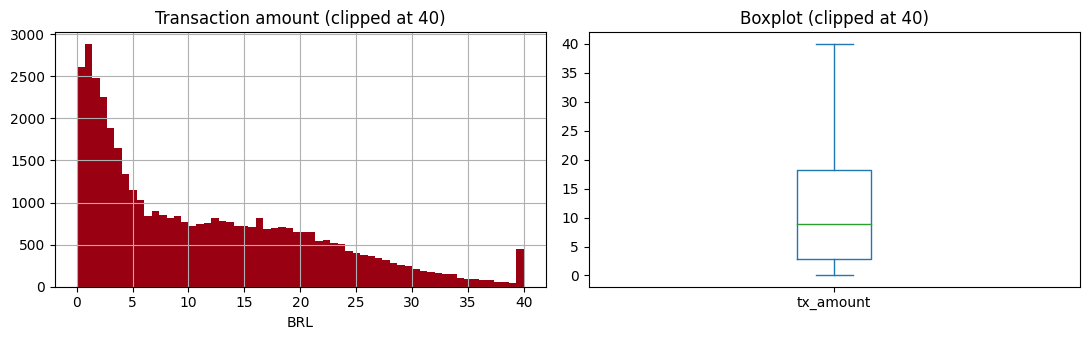

Missingness pattern (the three fields fail together):
+---------+-------+-----------+----------+------------------+
|customers|age_118|gender_null|limit_null|all_three_together|
+---------+-------+-----------+----------+------------------+
|    17000|   2175|       2175|      2175|              2175|
+---------+-------+-----------+----------+------------------+



In [0]:
sample = transactions.select("tx_amount").sample(0.3, seed=42).toPandas()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sample["tx_amount"].clip(upper=40).hist(bins=60, ax=ax[0], color="#990011")
ax[0].set_title("Transaction amount (clipped at 40)"); ax[0].set_xlabel("BRL")
sample["tx_amount"].clip(upper=40).plot(kind="box", ax=ax[1])
ax[1].set_title("Boxplot (clipped at 40)")
plt.tight_layout(); plt.show()

print("Missingness pattern (the three fields fail together):")
profile.select(
    F.count("*").alias("customers"),
    F.sum((F.col("age") == 118).cast("int")).alias("age_118"),
    F.sum(F.col("gender").isNull().cast("int")).alias("gender_null"),
    F.sum(F.col("credit_card_limit").isNull().cast("int")).alias("limit_null"),
    F.sum(((F.col("age") == 118) & F.col("gender").isNull()
           & F.col("credit_card_limit").isNull()).cast("int")).alias("all_three_together"),
).show()

## 5. Customer-offer instance table

One row per `offer received` event. The validity window is `[t0, t0 + duration]`.
Views and completions are attributed to the **most recent** instance of the same offer whose
window contains the event (this resolves customers who receive the same offer twice).

In [0]:
instances = (received_ev
    .withColumnRenamed("t_days", "t0")
    .join(offers.select(F.col("id").alias("offer_id"), "offer_type", "discount_value",
                        "min_value", "duration", "channels"), "offer_id")
    .withColumn("t_end", F.col("t0") + F.col("duration"))
    .withColumn("instance_id", F.monotonically_increasing_id())
)
N_INSTANCES = instances.count()
print(f"{N_INSTANCES:,} customer-offer instances")
assert N_INSTANCES == received_ev.count()

76,277 customer-offer instances


### 5.1 Attributing views and completions to instances

In [0]:
def attribute(events, flag_name, time_name, extra_aggs=None):
    """Attribute each event to the most recent instance (max t0) whose window contains it."""
    ev = events.withColumn("_eid", F.monotonically_increasing_id()).alias("e")
    candidates = ev.join(
        instances.alias("i"),
        (F.col("e.account_id") == F.col("i.account_id")) &
        (F.col("e.offer_id")   == F.col("i.offer_id")) &
        (F.col("e.t_days")     >= F.col("i.t0")) &
        (F.col("e.t_days")     <= F.col("i.t_end"))
    )
    w = Window.partitionBy("e._eid").orderBy(F.col("i.t0").desc())
    best = candidates.withColumn("_rk", F.row_number().over(w)).filter("_rk = 1")
    aggs = [F.lit(1).alias(flag_name), F.min("e.t_days").alias(time_name)]
    if extra_aggs:
        aggs += extra_aggs
    return best.groupBy("i.instance_id").agg(*aggs)

attr_view = attribute(viewed_ev, "viewed", "t_view")
attr_comp = attribute(completed_ev, "completed", "t_completion",
                      extra_aggs=[F.sum("e.reward_paid").alias("reward_window")])

instances = (instances
    .join(attr_view, "instance_id", "left")
    .join(attr_comp, "instance_id", "left")
    .fillna(0, ["viewed", "completed", "reward_window"])
)
instances.groupBy("offer_type").agg(
    F.avg("viewed").alias("view_rate"),
    F.avg("completed").alias("completion_rate"),
).show()

+-------------+------------------+------------------+
|   offer_type|         view_rate|   completion_rate|
+-------------+------------------+------------------+
|     discount| 0.699669318665488|0.5762367809318011|
|         bogo|0.8278959965900521|0.5082461720056395|
|informational|0.6529044962257958|               0.0|
+-------------+------------------+------------------+



### 5.2 Window overlap

A customer can have 2+ offers active simultaneously, which contaminates window-based transaction
attribution. We flag overlapping instances; the modeling notebook controls for the count in the
nuisance models and runs a sensitivity analysis on the clean subset.

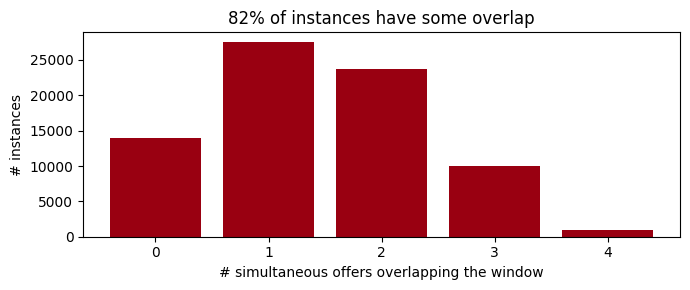

In [0]:
i, j = instances.alias("i"), instances.select("instance_id", "account_id", "t0", "t_end").alias("j")
overlaps = (i.join(j,
        (F.col("i.account_id") == F.col("j.account_id")) &
        (F.col("i.instance_id") != F.col("j.instance_id")) &
        (F.col("i.t0") <= F.col("j.t_end")) &
        (F.col("j.t0") <= F.col("i.t_end")))
    .groupBy("i.instance_id").agg(F.count("*").alias("n_overlapping_offers"))
)
instances = instances.join(overlaps, "instance_id", "left").fillna(0, ["n_overlapping_offers"])

ov = instances.groupBy("n_overlapping_offers").count().orderBy("n_overlapping_offers").toPandas()
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(ov["n_overlapping_offers"], ov["count"], color="#990011")
ax.set_xlabel("# simultaneous offers overlapping the window"); ax.set_ylabel("# instances")
ax.set_title(f"{(instances.filter('n_overlapping_offers > 0').count() / N_INSTANCES):.0%} of instances have some overlap")
plt.tight_layout(); plt.show()

## 6. Pre-treatment features (leakage-proof)

Golden rule: **every feature uses only information strictly before `t0`** (offer receipt).
This keeps the DML nuisance functions from "seeing the future".

### 6.1 Pre-offer RFM

In [0]:
tx = transactions.alias("t")
pre_rfm = (instances.alias("i")
    .join(tx, (F.col("t.account_id") == F.col("i.account_id")) &
              (F.col("t.t_days") < F.col("i.t0")), "left")
    .groupBy("i.instance_id")
    .agg(
        F.count("t.tx_amount").alias("freq_pre"),
        F.coalesce(F.sum("t.tx_amount"), F.lit(0.0)).alias("spend_pre"),
        F.avg("t.tx_amount").alias("avg_ticket_pre"),
        F.max("t.t_days").alias("_t_last_purchase"),
    )
)
instances = (instances.join(pre_rfm, "instance_id", "left")
    .withColumn("recency_pre", F.col("t0") - F.col("_t_last_purchase"))
    .drop("_t_last_purchase")
)

### 6.2 Offer history before `t0`

In [0]:
offer_events = (received_ev.withColumn("ev_type", F.lit("received_pre"))
    .unionByName(viewed_ev.withColumn("ev_type", F.lit("viewed_pre")))
    .unionByName(completed_ev.select("account_id", "offer_id", "t_days")
                 .withColumn("ev_type", F.lit("completed_pre")))
).alias("e")

offer_history = (instances.alias("i")
    .join(offer_events, (F.col("e.account_id") == F.col("i.account_id")) &
                        (F.col("e.t_days") < F.col("i.t0")), "left")
    .groupBy("i.instance_id").pivot("ev_type", ["received_pre", "viewed_pre", "completed_pre"])
    .agg(F.count("e.account_id"))
)
instances = instances.join(offer_history, "instance_id", "left") \
                     .fillna(0, ["received_pre", "viewed_pre", "completed_pre"])

### 6.3 Demographics

`age = 118` is treated as coded missing with an explicit `incomplete_profile` flag (Section 4.6
showed the three fields fail together — the missingness pattern itself is informative).
`tenure` is computed against the latest registration date observed (a proxy for the test start;
the exact mapping between calendar dates and `t = 0` is not provided).

In [0]:
ref_date = profile.select(F.max(F.to_date(F.col("registered_on").cast("string"), "yyyyMMdd"))).first()[0]

demo = (profile
    .withColumn("incomplete_profile", (F.col("age") == 118).cast("int"))
    .withColumn("age_clean", F.when(F.col("age") == 118, None).otherwise(F.col("age")))
    .withColumn("gender_clean", F.coalesce(F.col("gender"), F.lit("NA")))
    .withColumn("reg_date", F.to_date(F.col("registered_on").cast("string"), "yyyyMMdd"))
    .withColumn("tenure_days", F.datediff(F.lit(ref_date), F.col("reg_date")))
    .select(F.col("id").alias("account_id"), F.col("age_clean").alias("age"),
            F.col("gender_clean").alias("gender"), "credit_card_limit",
            "tenure_days", "incomplete_profile")
)
instances = instances.join(demo, "account_id", "left")
print(f"Reference date for tenure: {ref_date}")

Reference date for tenure: 2018-07-26


## 7. Outcome variables

**Why fixed horizons?** Offer durations range from 3 to 10 days *and vary with the treatment*
(informational: 3–4d; discounts: up to 10d). An outcome window tied to `duration` mechanically
inflates the measured effect of longer offers — with a ~78% weekly base purchase rate, a longer
window captures more baseline purchases regardless of any causal effect. Fixed horizons remove
this artifact:

| Outcome | Definition | Role |
|---|---|---|
| `y1_conv_7d` | ≥1 transaction in `(t0, t0 + CONV_HORIZON (= 7)]` | **Primary** — conversion. Transaction-based (not `offer completed`), hence comparable across `discount`, `BOGO` and `informational`. |
| `y2_retention` | ≥1 transaction in `(t0 + RETENTION_START (= 10), t0 + RETENTION_END (= 17)]` | **Retention proxy** — post-expiry engagement for *every* offer (max duration = 10d). Defined only where the window is observable (`y2_observable = 1`); censoring depends solely on the send wave (randomized), hence administrative, not selective. |
| `y3_net_value_7d` | 7-day spend − reward paid | **Business metric** — used for monetization. |

Offer-duration-window variants (`y1_offer_window`, spend/reward within `[t0, t_end]`) are kept as
robustness columns.

### 7.0 Checkpoint — break the accumulated lineage

Sections 5–6 chained several joins, window functions and a pivot. On serverless compute, every downstream action would re-execute that whole plan (no reliable `.cache()`), which is slow and can OOM. Materializing to parquet resets the lineage.

In [0]:
def checkpoint(df, name):
    """Materialize `df` to parquet and read it back, truncating the logical plan."""
    path = f"{DIR_PROCESSED}/_ckpt_{name}.parquet"
    df.write.mode("overwrite").parquet(path)
    return spark.read.parquet(path)

instances = checkpoint(instances, "instances_features")
print(f"Checkpoint: {instances.count():,} instances")

Checkpoint: 76,277 instances


### 7.1 Fixed-horizon outcomes (primary) — single-pass window aggregation

One range join covering `(t0, t0 + RETENTION_END]`; the two windows are separated by conditional aggregation (half the shuffle of two joins, and only 4 columns enter it).

In [0]:
base = instances.select("instance_id", "account_id", "t0").alias("i")
in_conv = (F.col("t.t_days") > F.col("i.t0")) & \
          (F.col("t.t_days") <= F.col("i.t0") + F.lit(CONV_HORIZON))
in_ret  = (F.col("t.t_days") > F.col("i.t0") + F.lit(RETENTION_START)) & \
          (F.col("t.t_days") <= F.col("i.t0") + F.lit(RETENTION_END))

agg_fixed = (base
    .join(tx, (F.col("t.account_id") == F.col("i.account_id")) &
              (F.col("t.t_days") >  F.col("i.t0")) &
              (F.col("t.t_days") <= F.col("i.t0") + F.lit(RETENTION_END)), "left")
    .groupBy("i.instance_id")
    .agg(F.count(F.when(in_conv, 1)).alias("n_tx_7d"),
         F.coalesce(F.sum(F.when(in_conv, F.col("t.tx_amount"))), F.lit(0.0)).alias("spend_7d"),
         F.count(F.when(in_ret, 1)).alias("n_tx_retention"))
)

instances = (instances
    .join(agg_fixed, "instance_id", "left")
    .fillna(0, ["n_tx_7d", "spend_7d", "n_tx_retention"])
    .withColumn("y1_conv_7d", (F.col("n_tx_7d") > 0).cast("int"))
    .withColumn("y2_observable", (F.col("t0") + F.lit(RETENTION_END) <= F.lit(T_MAX_DAYS)).cast("int"))
    .withColumn("y2_retention", F.when(F.col("y2_observable") == 1,
                                       (F.col("n_tx_retention") > 0).cast("int")))
    # reward from the offer's own window (conservative: overstates cost for long offers)
    .withColumn("y3_net_value_7d", F.col("spend_7d") - F.col("reward_window"))
)

### 7.2 Offer-duration-window outcomes (robustness)

In [0]:
in_window = (F.col("t.t_days") > F.col("i.t0")) & (F.col("t.t_days") <= F.col("i.t_end"))
base_w = instances.select("instance_id", "account_id", "t0", "t_end").alias("i")

agg_window = (base_w
    .join(tx, (F.col("t.account_id") == F.col("i.account_id")) &
              (F.col("t.t_days") >  F.col("i.t0")) &
              (F.col("t.t_days") <= F.col("i.t_end")), "left")
    .groupBy("i.instance_id")
    .agg(F.count(F.when(in_window, 1)).alias("n_tx_offer_window"),
         F.coalesce(F.sum(F.when(in_window, F.col("t.tx_amount"))), F.lit(0.0)).alias("spend_offer_window"))
)
instances = (instances.join(agg_window, "instance_id", "left")
    .fillna(0, ["n_tx_offer_window", "spend_offer_window"])
    .withColumn("y1_offer_window", (F.col("n_tx_offer_window") > 0).cast("int"))
)

instances = checkpoint(instances, "instances_outcomes")
instances.groupBy("offer_type").agg(
    F.count("*").alias("n"),
    F.avg("y1_conv_7d").alias("y1_7d_rate"),
    F.avg("y1_offer_window").alias("y1_window_rate_(robustness)"),
    F.avg("y2_observable").alias("y2_observable_share"),
    F.avg("y2_retention").alias("y2_rate_(obs)"),
    F.avg("y3_net_value_7d").alias("y3_mean"),
).orderBy("offer_type").show()

+-------------+-----+------------------+---------------------------+-------------------+------------------+------------------+
|   offer_type|    n|        y1_7d_rate|y1_window_rate_(robustness)|y2_observable_share|     y2_rate_(obs)|           y3_mean|
+-------------+-----+------------------+---------------------------+-------------------+------------------+------------------+
|         bogo|30499|0.8227810747893374|         0.7945834289648841|0.33233876520541655| 0.819258089976322| 24.43376045116235|
|     discount|30543|0.8115771207805389|         0.8439904397079527|0.33094326032151394|0.8090621290067274|27.527244540483927|
|informational|15235|0.7751230718739744|         0.6027568099770266| 0.3331145388907122|0.8254187192118226|21.694572366261905|
+-------------+-----+------------------+---------------------------+-------------------+------------------+------------------+



### 7.3 EDA — conversion stability across waves (heatmap)

Roughly uniform columns confirm the experiment is stable over time and allocation did not drift.

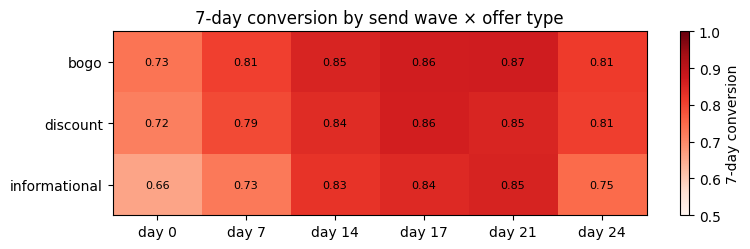

In [0]:
import numpy as np
hm = (instances.groupBy("t0", "offer_type").agg(F.avg("y1_conv_7d").alias("rate"))
      .toPandas().pivot(index="offer_type", columns="t0", values="rate"))
fig, ax = plt.subplots(figsize=(8, 2.6))
im = ax.imshow(hm.values, cmap="Reds", aspect="auto", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels([f"day {int(c)}" for c in hm.columns])
ax.set_yticks(range(len(hm.index)));  ax.set_yticklabels(hm.index)
for r in range(hm.shape[0]):
    for c in range(hm.shape[1]):
        ax.text(c, r, f"{hm.values[r, c]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="7-day conversion")
ax.set_title("7-day conversion by send wave × offer type")
plt.tight_layout(); plt.show()

### 7.4 EDA — time to first purchase after receipt (ECDF)

How fast the response materializes, by offer type — level differences echo the ATEs; the shape shows the dynamics.

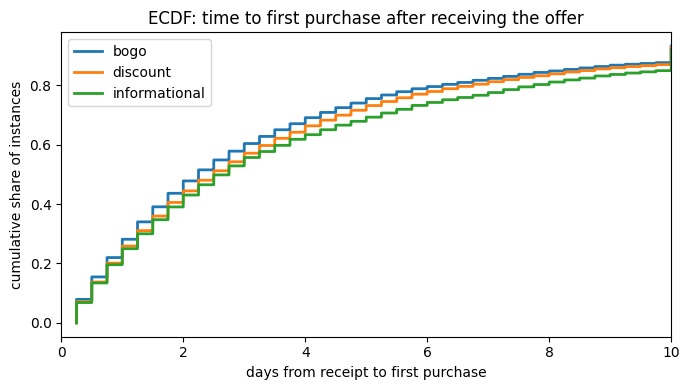

In [0]:
first_tx = (instances.select("instance_id", "account_id", "t0", "offer_type").alias("i")
    .join(tx, (F.col("t.account_id") == F.col("i.account_id")) &
              (F.col("t.t_days") > F.col("i.t0")), "left")
    .groupBy("i.instance_id", "i.offer_type", "i.t0")
    .agg(F.min("t.t_days").alias("t_first"))
    .withColumn("days_to_first", F.col("t_first") - F.col("t0"))
    .select("offer_type", "days_to_first").toPandas())

fig, ax = plt.subplots(figsize=(7, 4))
for otype, g in first_tx.groupby("offer_type"):
    d = g["days_to_first"].dropna().clip(upper=10).sort_values()
    # ECDF over ALL instances of the type (non-purchasers keep the curve honest below 1.0)
    ax.step(d, np.arange(1, len(d) + 1) / len(g), where="post", label=otype, lw=2)
ax.set_xlabel("days from receipt to first purchase"); ax.set_ylabel("cumulative share of instances")
ax.set_xlim(0, 10); ax.legend(); ax.set_title("ECDF: time to first purchase after receiving the offer")
plt.tight_layout(); plt.show()

### 7.5 EDA — spending inside vs. outside active offer windows

Do customers change the *size* of their purchases when an offer is active, or only the timing/frequency?

In [0]:
win = instances.select("account_id", "t0", "t_end").alias("w")
tx_flagged = (tx.join(win, (F.col("t.account_id") == F.col("w.account_id")) &
                           (F.col("t.t_days") > F.col("w.t0")) &
                           (F.col("t.t_days") <= F.col("w.t_end")), "left")
    .groupBy("t.account_id", "t.t_days", "t.tx_amount")
    .agg(F.max(F.col("w.t0").isNotNull().cast("int")).alias("inside_active_window"))
)
tx_flagged.groupBy("inside_active_window").agg(
    F.count("*").alias("n_tx"),
    F.avg("tx_amount").alias("avg_ticket"),
    F.expr("percentile_approx(tx_amount, 0.5)").alias("median_ticket"),
).orderBy("inside_active_window").show()

+--------------------+------+------------------+-------------+
|inside_active_window|  n_tx|        avg_ticket|median_ticket|
+--------------------+------+------------------+-------------+
|                   0| 18694| 12.73708516101421|         9.67|
|                   1|120259|12.783616195045616|         8.79|
+--------------------+------+------------------+-------------+



## 8. Treatment variables

- `discount_intensity = discount_value / min_value` — a continuous treatment summary
  (0 for `informational`, which acts as the zero-discount level while holding the
  communication effect constant).
- One-hot channels (channel mix is an attribute of the *offer*, i.e. part of the treatment
  package — which is why channels are **excluded** from the feature/control sets in Notebook 2).

In [0]:
instances = (instances
    .withColumn("discount_intensity",
                F.when(F.col("min_value") > 0, F.col("discount_value") / F.col("min_value"))
                 .otherwise(F.lit(0.0)))
    .withColumn("ch_web",    F.array_contains("channels", "web").cast("int"))
    .withColumn("ch_email",  F.array_contains("channels", "email").cast("int"))
    .withColumn("ch_mobile", F.array_contains("channels", "mobile").cast("int"))
    .withColumn("ch_social", F.array_contains("channels", "social").cast("int"))
)
instances.groupBy("offer_type", "discount_value", "min_value", "discount_intensity") \
         .count().orderBy("offer_type", "discount_intensity").show()

+-------------+--------------+---------+-------------------+-----+
|   offer_type|discount_value|min_value| discount_intensity|count|
+-------------+--------------+---------+-------------------+-----+
|         bogo|            10|       10|                1.0|15251|
|         bogo|             5|        5|                1.0|15248|
|     discount|             2|       10|                0.2|15229|
|     discount|             5|       20|               0.25| 7668|
|     discount|             3|        7|0.42857142857142855| 7646|
|informational|             0|        0|                0.0|15235|
+-------------+--------------+---------+-------------------+-----+



## 9. Balance checks

If offer allocation was randomized (as the test design suggests), pre-treatment covariates must be
balanced across arms. Then DML serves **variance reduction and heterogeneity estimation**, not
confounding correction — we verify empirically instead of assuming.

In [0]:
bal = instances.groupBy("offer_type").agg(
    F.count("*").alias("n"),
    F.avg("age").alias("mean_age"),
    F.avg("credit_card_limit").alias("mean_limit"),
    F.avg("tenure_days").alias("mean_tenure"),
    F.avg("freq_pre").alias("mean_freq_pre"),
    F.avg("spend_pre").alias("mean_spend_pre"),
    F.avg((F.col("gender") == "F").cast("int")).alias("share_female"),
    F.avg("incomplete_profile").alias("share_incomplete"),
)
bal.orderBy("offer_type").show()

print("Correlation between discount intensity and pre-treatment covariates (expected ~0 under randomization):")
for c in ["age", "credit_card_limit", "tenure_days", "freq_pre", "spend_pre"]:
    print(f"  corr(intensity, {c:18s}) = {instances.stat.corr('discount_intensity', c):+.4f}")

+-------------+-----+-----------------+-----------------+-----------------+------------------+-----------------+-------------------+-------------------+
|   offer_type|    n|         mean_age|       mean_limit|      mean_tenure|     mean_freq_pre|   mean_spend_pre|       share_female|   share_incomplete|
+-------------+-----+-----------------+-----------------+-----------------+------------------+-----------------+-------------------+-------------------+
|         bogo|30499|54.33255454648227|65424.57700569017|518.0211154464081|3.4619495721171187| 43.8529387848782|  0.359847863864389|0.12990589855405096|
|     discount|30543|54.31071857185719|65318.85688568857|515.1322397930786|3.4434731362341617|43.18710899387751|0.35828176668958517|0.12700127688832138|
|informational|15235|54.55984962406015|65371.72932330827|518.8796849360026| 3.472399081063341|45.00515523465704| 0.3635050869707909|0.12701017394158187|
+-------------+-----+-----------------+-----------------+-----------------+-------

## 10. Final unified dataset

In [0]:
final_columns = [
    # identifiers
    "instance_id", "account_id", "offer_id",
    # treatment
    "offer_type", "discount_value", "min_value", "duration", "discount_intensity",
    "ch_web", "ch_email", "ch_mobile", "ch_social",
    # window / design
    "t0", "t_end", "n_overlapping_offers",
    # pre-treatment features
    "age", "gender", "credit_card_limit", "tenure_days", "incomplete_profile",
    "freq_pre", "spend_pre", "avg_ticket_pre", "recency_pre",
    "received_pre", "viewed_pre", "completed_pre",
    # mediators / diagnostics (post-treatment -- NEVER use as features)
    "viewed", "completed",
    # outcomes (fixed-horizon = primary; offer-window = robustness)
    "y1_conv_7d", "n_tx_7d", "spend_7d",
    "y2_observable", "y2_retention",
    "y3_net_value_7d", "reward_window",
    "y1_offer_window", "n_tx_offer_window", "spend_offer_window",
]

# --- Write first (single execution of the lineage), then validate the parquet ---
output_path = f"{DIR_PROCESSED}/dataset_unified.parquet"
instances.select(*final_columns).write.mode("overwrite").parquet(output_path)
dataset = spark.read.parquet(output_path)

# --- Integrity checks ------------------------------------------------------
assert dataset.count() == N_INSTANCES, "instances lost/duplicated in joins"
assert dataset.filter("recency_pre < 0").count() == 0, "leakage: negative recency"
assert dataset.filter("y2_observable = 0 AND y2_retention IS NOT NULL").count() == 0
assert dataset.select("instance_id").distinct().count() == N_INSTANCES, "duplicated instance_id"

print(f"OK — {dataset.count():,} rows x {len(final_columns)} columns written to {output_path}")
dataset.printSchema()

OK — 76,277 rows x 39 columns written to /Volumes/workspace/default/ifood_case/processed/dataset_unified.parquet
root
 |-- instance_id: long (nullable = true)
 |-- account_id: string (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- offer_type: string (nullable = true)
 |-- discount_value: long (nullable = true)
 |-- min_value: long (nullable = true)
 |-- duration: double (nullable = true)
 |-- discount_intensity: double (nullable = true)
 |-- ch_web: integer (nullable = true)
 |-- ch_email: integer (nullable = true)
 |-- ch_mobile: integer (nullable = true)
 |-- ch_social: integer (nullable = true)
 |-- t0: double (nullable = true)
 |-- t_end: double (nullable = true)
 |-- n_overlapping_offers: long (nullable = true)
 |-- age: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- tenure_days: integer (nullable = true)
 |-- incomplete_profile: integer (nullable = true)
 |-- freq_pre: long (nullable = true)
 |-- s

In [0]:
dataset.select("y1_conv_7d", "y2_retention", "y3_net_value_7d",
               "discount_intensity", "freq_pre", "recency_pre").summary(
               "count", "mean", "stddev", "min", "50%", "max").show()

+-------+------------------+-------------------+------------------+------------------+------------------+------------------+
|summary|        y1_conv_7d|       y2_retention|   y3_net_value_7d|discount_intensity|          freq_pre|       recency_pre|
+-------+------------------+-------------------+------------------+------------------+------------------+------------------+
|  count|             76277|              25319|             76277|             76277|             76277|             55325|
|   mean|0.8087759088585026| 0.8164224495438208|25.125354956277796|0.5078681272579703|3.4566383051247427|3.3540307275192047|
| stddev|0.3932676769218349|0.38714694006088235| 52.55493165702495|0.4178494283601294|3.6667513821061917|   3.0831821759428|
|    min|                 0|                  0|             -20.0|               0.0|                 0|              0.25|
|    50%|                 1|                  1|             10.76|              0.25|                 3|               2.5|


## 11. Assumptions and documented decisions

1. **Unit of analysis:** instance (customer, offer received). A customer contributes multiple rows;
   all inference in Notebook 2 groups by customer (train/test split, cross-fitting, standard errors).
2. **Treatment = receipt (intention-to-treat):** viewing is post-treatment (affected by channels and
   customer behavior); conditioning on it would introduce selection bias. `viewed`/`completed` remain
   in the dataset for diagnostics only.
3. **Comparison group:** `informational` offers (zero discount) — holds the effect of "receiving a
   communication" constant, isolating the effect of the *discount package*.
4. **`y1` is transaction-based**, not completion-based: completion does not exist for `informational`
   and depends on `min_value`, which would make it incomparable across offer types.
5. **Fixed-horizon outcomes as primary:** offer durations vary with treatment, so duration-tied
   windows mechanically confound effect estimates (we measured a ~20 p.p. artifact before the fix).
   Offer-window variants are kept as robustness columns.
6. **Retention proxy (`y2`):** purchase in days 10–17 after receipt (post-expiry for every offer,
   since max duration = 10d). Censoring depends only on the send wave — administrative, not selective.
   The ~30-day test makes true long-run retention unobservable.
7. **Transactions attributed by time window** (they carry no offer_id); overlapping windows are
   counted in `n_overlapping_offers` for control and sensitivity analysis.
8. **`age = 118` treated as coded missing** with an `incomplete_profile` flag (the three profile
   fields fail together; the pattern is informative and used as a feature).
9. **`tenure` relative to the max registration date** observed (proxy for the test start; the exact
   calendar mapping of `t = 0` is not provided).
10. **Time unit auto-detected** (hours vs. days) for robustness across dataset versions.

**Next step (Notebook 2):** multi-valued treatment CATE (8 active offers vs. informational) with
CausalForestDML, model comparison via R-loss, randomization-based inference for average effects,
policy optimization with doubly-robust off-policy evaluation, and an interpretable policy tree.
